In [31]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [32]:
#read in data, fix columns
df = (pd.read_csv("polarizer_correlation.csv")
      .drop(columns=['Trial Number', 'Angle A'])
      .rename(columns={
          "Angle B": "ANGLE",
          "N_coin / time": "COIN_RATE",
          "TIME [s]": "TIME"
      }))
df['E_N_COIN'] = np.sqrt(df['N_COIN'])
df['E_COIN_RATE'] = df['E_N_COIN'] / df['TIME']
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


In [33]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [34]:
def model(x, phase, amplitude, baseline):
    x = np.array(x)
    y = amplitude * np.cos(x * np.pi / 90 + phase * np.pi/180) + baseline
    return y

In [35]:
def chi_sq(theta, uncertainty_multiplier = 1):
    y_mod = model(df["ANGLE"], *theta)
    y_data = df["COIN_RATE"]
    return np.sum((y_data - y_mod)**2/(df['E_COIN_RATE'] * uncertainty_multiplier)**2) / len(df - len(theta))

In [36]:
p0 = [0, 750, 750]
pcurve_fit, ecurve_fit = curve_fit(model, df['ANGLE'], df['COIN_RATE'], p0)

7.8429111520224675


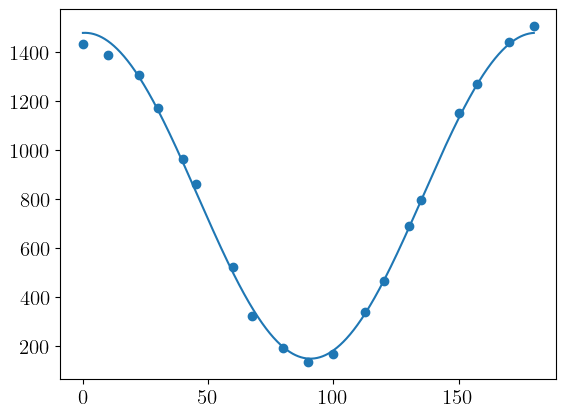

In [37]:
plt.scatter(df["ANGLE"], df["COIN_RATE"])
x = np.linspace(0, 180, 1000)
plt.plot(x, model(x, *pcurve_fit))
print(chi_sq(pcurve_fit))

In [38]:
#mcmc prior
def log_prior(theta):
    if np.any(theta[1:] < 0):
        return -np.inf
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/df['E_COIN_RATE']**2)

In [39]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [44]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 3000, progress=True)

  0%|          | 0/3000 [00:00<?, ?it/s]

100%|██████████| 3000/3000 [00:13<00:00, 223.56it/s]


State([[ -1.48735077 673.67125444 811.01349982]
 [ -1.59035023 676.52251699 812.67853978]
 [ -1.58517714 671.31614243 811.16165634]
 [ -1.53020822 672.52368044 811.85633767]
 [ -1.50573124 673.75215267 812.17745931]
 [ -1.64029177 675.97269665 813.73147624]
 [ -1.58162062 672.7950415  812.70763343]
 [ -1.49185498 674.38694115 813.88776719]
 [ -1.63327779 674.99764631 815.00103228]
 [ -1.46718218 676.18890423 813.40609011]
 [ -1.49579756 675.52767917 813.12593074]
 [ -1.63385872 676.64133989 815.02499887]
 [ -1.56717963 675.42709783 814.03945148]
 [ -1.44519655 676.29322751 814.52509627]
 [ -1.8025575  673.69651866 812.86045485]
 [ -1.4354421  675.14503341 812.66689911]], log_prob=[-129.7512255  -130.4805141  -130.49463829 -129.49127964 -129.05821497
 -129.93599527 -129.73413861 -129.56847215 -131.06317804 -129.60461937
 -129.26031953 -130.87425311 -129.59883388 -129.99667073 -131.0567931
 -129.24756888], blobs=None, random_state=('MT19937', array([2151114860,  326660964, 1550403614, 19

In [45]:
#names of parameters
param_labels = [
    "Phase",
    "Amplitude",
    "Baseline"
]

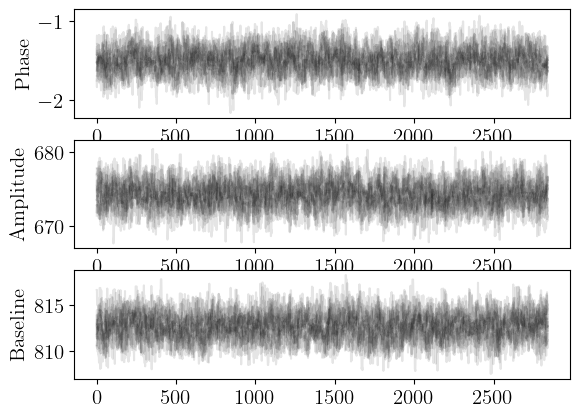

In [46]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

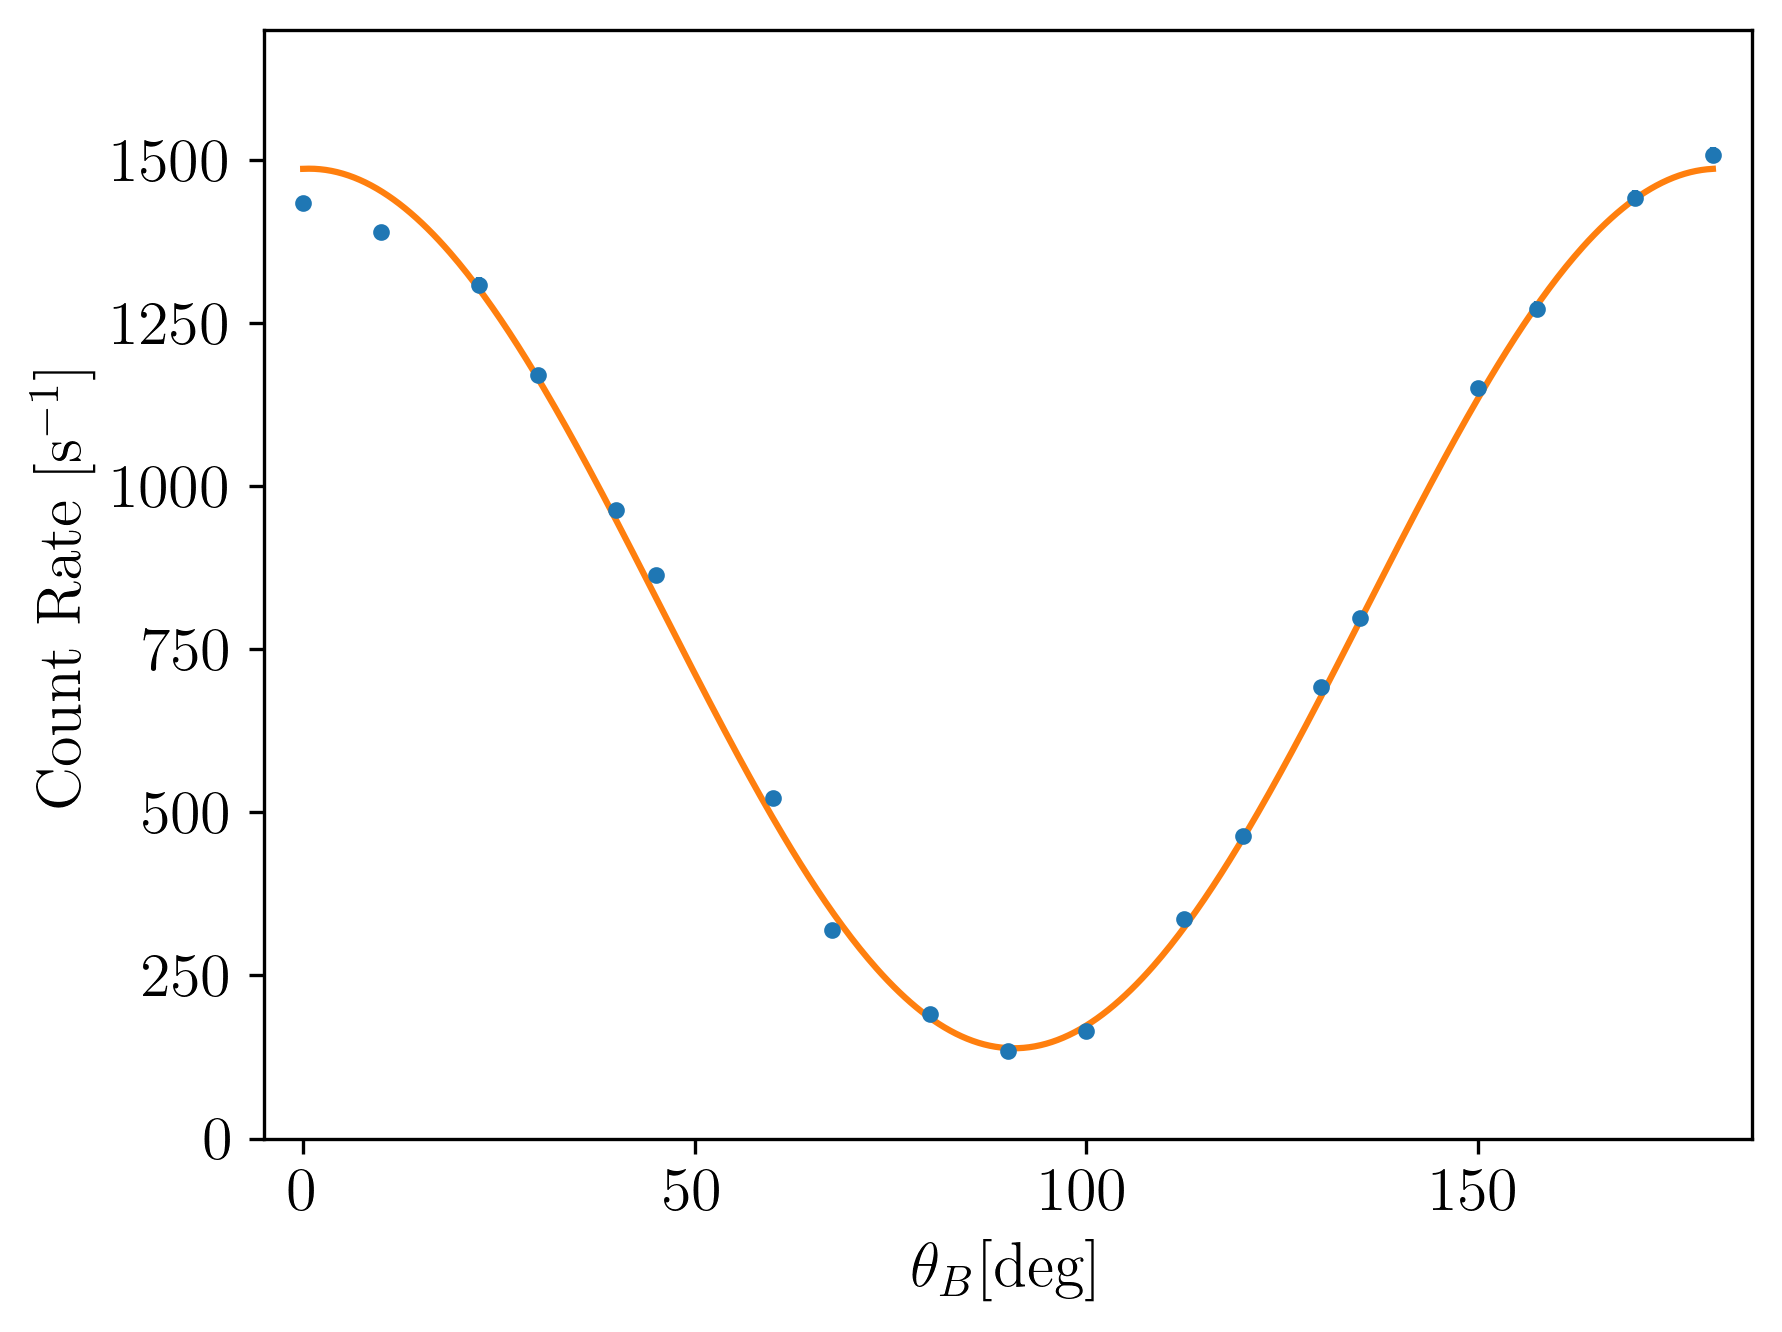

In [47]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"], ls="", marker=".")
x = np.linspace(0, 180, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)

ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit.png", bbox_inches = "tight")

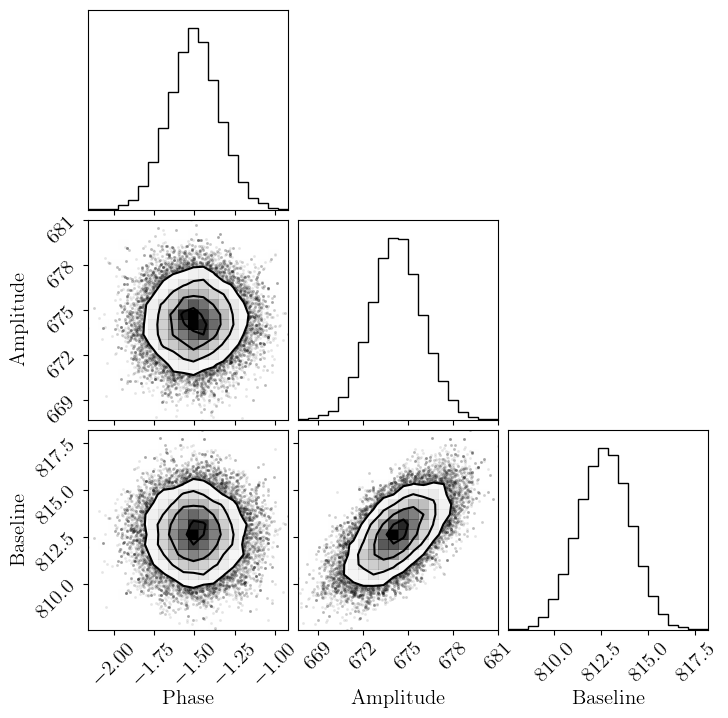

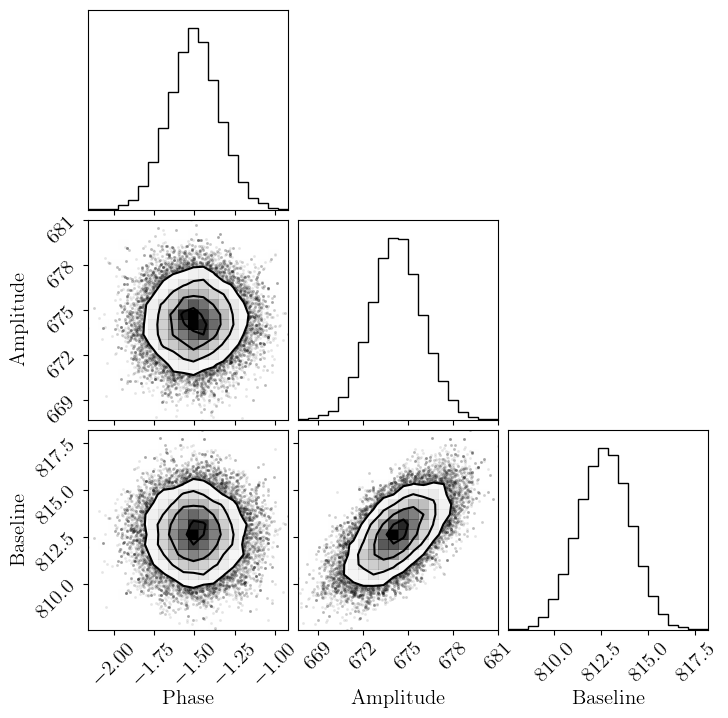

In [48]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels)

In [49]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [50]:

results.to_csv("mcmc_fit.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.498063,0.157753,0.315506,-0.210609
Amplitude,674.272305,1.738480,3.476960,0.005157
Baseline,812.703694,1.396053,2.792107,0.003436


In [51]:
chi_sq_mcmc = chi_sq(np.median(chain, axis = 0))
chi_sq_mcmc
#quite high, will try rescaling errors 

np.float64(6.789583788017821)

In [54]:
#mcmc log likelihood
def log_prob_adjusted(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/(df['E_COIN_RATE'] * np.sqrt(chi_sq_mcmc))**2)

In [55]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [61]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob_adjusted)
sampler.run_mcmc(x0, 3000, progress=True)

100%|██████████| 3000/3000 [00:14<00:00, 201.13it/s]


State([[ -1.95656865 671.00329126 813.01188748]
 [ -1.35614282 675.42228833 812.62668574]
 [ -0.99130366 673.71487693 814.5349339 ]
 [ -1.37093582 669.29865823 808.39453619]
 [ -1.75769464 676.86727695 816.99847082]
 [ -1.66078564 678.86548623 818.6719735 ]
 [ -1.08904423 679.91014246 817.84767713]
 [ -1.3961691  675.42129579 811.15099846]
 [ -1.71916095 674.07738984 806.73989471]
 [ -2.05741513 666.86440448 808.38156626]
 [ -1.25956916 675.44423895 811.66575234]
 [ -1.58388592 676.5937291  811.74542755]
 [ -1.17971379 674.94290947 812.6728766 ]
 [ -1.05144282 676.74524321 810.12884216]
 [ -0.93277018 673.56182729 810.070426  ]
 [ -1.47950055 673.54326266 811.42274095]], log_prob=[-20.08640937 -19.10276529 -20.04010434 -19.78763049 -19.91273566
 -20.39204574 -20.54709639 -19.3028823  -21.14133277 -21.16643615
 -19.3254924  -19.40033452 -19.29952512 -20.49964155 -20.19947784
 -19.05407378], blobs=None, random_state=('MT19937', array([2288390005,  359924409,   88116023, 3469055627, 30350

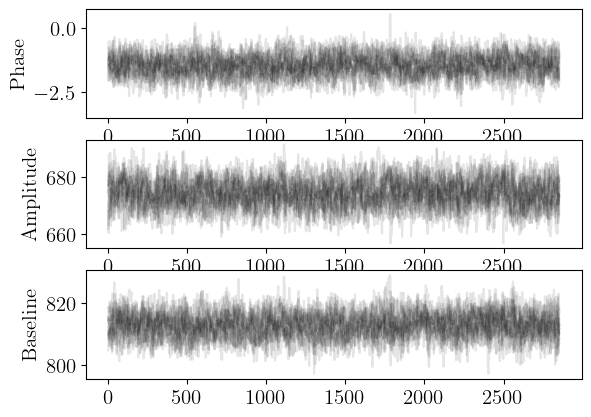

In [62]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

1.0000937209113299


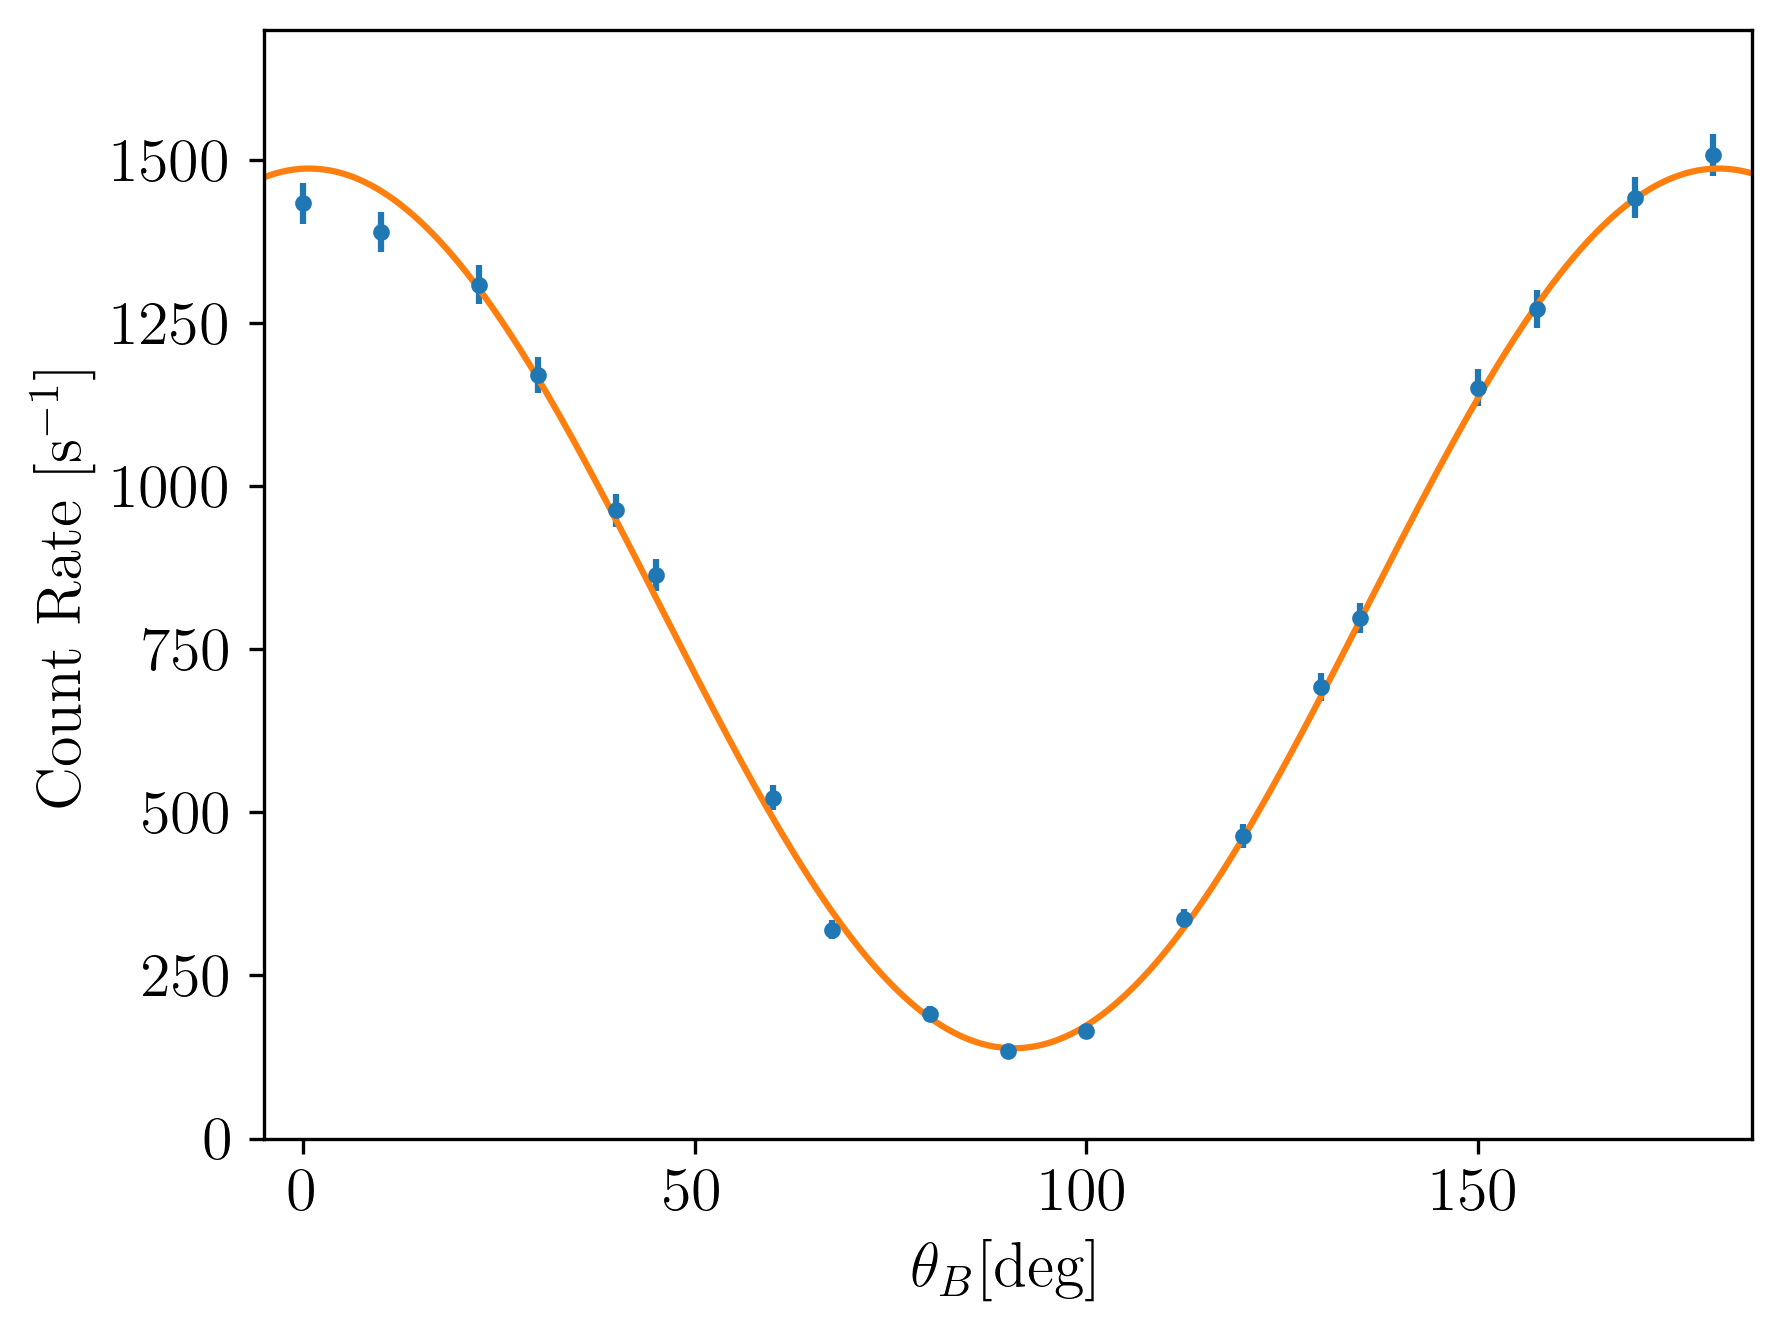

In [63]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit_adjusted_sigma.png", bbox_inches = "tight")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))

In [64]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [65]:
results.to_csv("mcmc_fit_adjusted.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.478390,0.398976,0.797952,-0.539744
Amplitude,674.381472,4.688559,9.377117,0.013905
Baseline,812.837407,3.809612,7.619224,0.009374
